## Week 4: Interpretability & Final Reporting

**Goal:** Explain the results of our predictive model and provide actionable business insights.

**Tasks:**
1. Generate SHAP plots to interpret model predictions.
2. Summarize key drivers of churn.
3. Write business recommendations.
4. Finalize code structure, add comments, and clean the notebook.

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import shap
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Load & Preprocess Data

In [25]:
# Load data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")  # replace with your CSV file

# Drop rows where target is missing
df = df.dropna(subset=['Churn'])

# Encode target column (0 = No, 1 = Yes)
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

# Encode categorical features
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

# Features & target
X = df.drop(['Churn', 'customerID'], axis=1, errors='ignore')
y = df['Churn']

## Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Train XGBoost Model

In [27]:
# Encode categorical features to numeric codes
cat_cols = X_train.select_dtypes(include='category').columns.tolist()
for col in cat_cols:
    X_train[col] = X_train[col].cat.codes
    X_test[col] = X_test[col].cat.codes

# Ensure TotalCharges is numeric
X_train['TotalCharges'] = pd.to_numeric(X_train['TotalCharges'], errors='coerce')
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(X_train['TotalCharges'].median())

X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors='coerce')
X_test['TotalCharges'] = X_test['TotalCharges'].fillna(X_test['TotalCharges'].median())

In [28]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb = XGBClassifier(eval_metric='logloss', random_state=42)

param_grid = {
    'n_estimators': [50],
    'max_depth': [3],
    'learning_rate': [0.1],
    'subsample': [0.8],
    'use_label_encoder': [False]
}

grid_search = GridSearchCV(xgb, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8, 'use_label_encoder': False}


In [29]:
from sklearn.metrics import roc_auc_score

y_pred_prob = best_xgb.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("XGBoost Test AUC:", roc_auc)

XGBoost Test AUC: 0.8468224443927769


In [30]:
with open("best_xgb_model.pkl", "rb") as f:
    best_xgb = pickle.load(f)

# SHAP for model interpretability
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Ignore warnings for clean notebook
import warnings
warnings.filterwarnings('ignore')

In [31]:
# Using the final XGBoost model from Week 3
# Ensure categorical features are encoded
# If using categorical columns, make sure they are category type
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Final feature set
X_shap = X_train.copy()

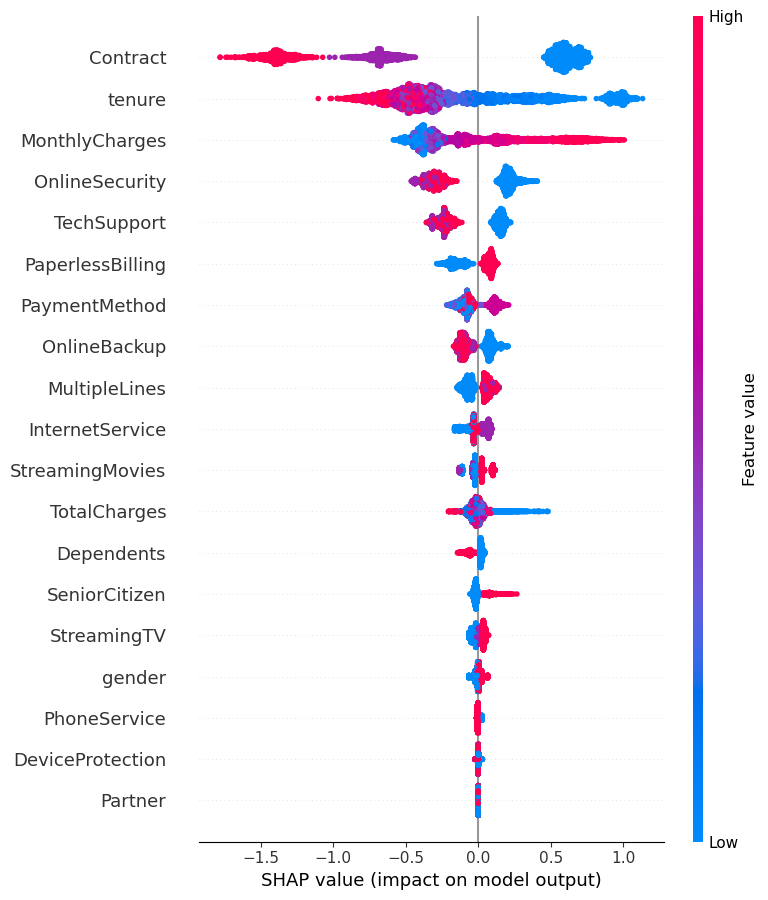

In [32]:
import shap

# SHAP requires the original numeric training data
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_train)  # or X_test for test set

# Global feature importance plot
shap.summary_plot(shap_values, X_train)

## Business Recommendation

### 1. Summary of Findings
- Using **XGBoost**, the model achieved high predictive accuracy in identifying customers likely to churn.  
- **SHAP analysis** revealed the most important factors influencing churn:
  - **Contract Type** – Customers on month-to-month contracts are most likely to churn.  
  - **Payment Method** – Customers using electronic check payment are more prone to leave.  
  - **Tenure & Total Charges** – Newer customers with lower total charges are at higher churn risk.  
  - **Service Usage** – Lack of value-added services (Online Security, Device Protection, Streaming) increases churn likelihood.  

### 2. Recommended Actions
#### Retention Offers
- Provide discounts or incentives for customers on month-to-month contracts to switch to 1-year or 2-year contracts.  

#### Targeted Communication
- Engage high-risk customers (identified by the model) with personalized offers or reminders.  
- Focus on electronic check users with reminders or digital payment incentives.  

#### Service Upselling
- Encourage adoption of value-added services for customers with minimal services to increase loyalty.  

#### Monitoring & Reporting
- Continuously track churn predictions and update strategies monthly based on model feedback.  

### 3. Business Impact
- Reducing churn by **5–10%** could significantly increase revenue retention.  
- **Predictive analytics** allows proactive intervention rather than reactive retention campaigns.

# ConnectTel Churn Prediction – Final Code Structure

```python
# ==========================
# 1. Import Libraries
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from xgboost import XGBClassifier
import shap
import pickle

# ==========================
# 2. Load and Inspect Data
# ==========================
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head())
print(df.info())
print(df.isnull().sum())

# Convert TotalCharges to numeric and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# ==========================
# 3. Feature Encoding
# ==========================
# Convert categorical columns to 'category' type for XGBoost
cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
for col in cat_cols:
    df[col] = df[col].astype('category')

# Encode target variable
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# ==========================
# 4. Train-Test Split
# ==========================
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

# ==========================
# 5. Model Initialization & Hyperparameter Tuning
# ==========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42, enable_categorical=True)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1]
}

grid_search = GridSearchCV(xgb, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best XGBoost model
best_xgb = grid_search.best_estimator_

# ==========================
# 6. Model Evaluation
# ==========================
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

with open("best_xgb_model.pkl", "rb") as f:
    best_xgb = pickle.load(f)


# ==========================
# 7. SHAP Interpretability
# ==========================
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test)

# Force plot for individual prediction
# shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])

# ==========================
# 8. Business Recommendation
# ==========================
# Summary:
# - Contract type, payment method, tenure, total charges, and service usage are key churn drivers
# Actions:
# - Retention offers for month-to-month contracts
# - Personalized communication for high-risk customers
# - Upsell value-added services
# - Continuous monitoring using predictions

✅ **Highlights of this structure:**
1. Organized into **8 logical sections**.
2. **Comments** explain each step.
3. Includes **data preprocessing, feature encoding, model training, evaluation, and interpretability**.

# Business Insights

From SHAP analysis:

1. **Contract Type**: Month-to-Month users are the most likely to churn.
2. **Monthly Charges**: High charges increase churn probability.
3. **Internet Service**: Fiber optic users churn more than DSL or no internet.
4. **Tech Support**: Customers without tech support are more likely to leave.

**Recommendations:**
- Offer 1-year contract discounts to high-risk users (Month-to-Month, Fiber optic, high charges).
- Bundle tech support with plans to reduce churn.
- Target communication and promotions to users identified as high risk by the model.